# Mangalyaan (Mars Orbiter Mission) Mars Orbit Insertion (MOI) - Telemetry EDA

This notebook performs an in-depth Exploratory Data Analysis (EDA) on the simulated telemetry dataset recorded during the Mars Orbit Insertion (MOI) maneuver of ISRO's **Mangalyaan** (Mars Orbiter Mission - MOM) on **September 24, 2014**.

### Telemetry Channels:
- `utc_time`: ISO-8601 UTC timestamp (1 Hz telemetry sampling).
- `TOF_Alt`: Time-of-Flight Radar / Altimeter altitude relative to the Martian surface (km).
- `Magx, Magy, Magz`: 3-axis Magnetometer readings.
- `Mag_heading`: Derived magnetic heading (degrees [0, 360)).
- `accelx, accely, accelz`: 3-axis Accelerometer readings (m/s²).
- `angle roll, pitch, yaw`: Spaceship attitude Euler angles (degrees).
- `ldr`: Light Dependent Resistor (optical solar flux / sun sensor illumination index).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import inv

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

data_path = os.path.join("..", "data", "mangalyaan_mars_orbit_insertion_simulated.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "mangalyaan_mars_orbit_insertion_simulated.csv")

df = pd.read_csv(data_path)
df['utc_time'] = pd.to_datetime(df['utc_time'])
df['elapsed_sec'] = (df['utc_time'] - df['utc_time'].iloc[0]).dt.total_seconds()

# Compute physics vector magnitudes
df['accel_mag'] = np.sqrt(df['accelx']**2 + df['accely']**2 + df['accelz']**2)
df['mag_total'] = np.sqrt(df['Magx']**2 + df['Magy']**2 + df['Magz']**2)

print(f"Loaded telemetry: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Loaded telemetry: 3600 rows, 16 columns.


,utc_time,TOF_Alt,Magx,Magy,Magz,Mag_heading,accelx,accely,accelz,angle roll,pitch,yaw,ldr,elapsed_sec,accel_mag,mag_total
0,2014-09-24 01:30:00+00:00,2500.107,3.2454,2.2978,0.1888,35.299,0.03670,0.07591,0.01884,0.0524,-3.0232,149.9144,0.68019,0.0,0.086395,3.980974
1,2014-09-24 01:30:01+00:00,2499.621,3.4605,2.2865,0.1307,33.454,-0.00088,0.09949,0.03307,-0.0164,-2.9846,150.1499,0.68598,1.0,0.104846,4.149726
2,2014-09-24 01:30:02+00:00,2500.213,2.8855,2.2599,0.1345,38.068,-0.02911,0.04328,0.00529,0.0314,-2.8770,149.8942,0.68270,2.0,0.052426,3.667608
3,2014-09-24 01:30:03+00:00,2500.231,3.3095,2.1946,0.1300,33.549,0.01165,0.04635,0.05092,0.1056,-2.9706,150.0605,0.68240,3.0,0.069835,3.973155
4,2014-09-24 01:30:04+00:00,2499.157,3.0999,2.1104,0.1391,34.246,-0.00198,0.05476,-0.03112,0.1350,-2.9549,149.9709,0.68536,4.0,0.063016,3.752668


## 1. Data Integrity & Descriptive Statistics
Verify missing values, duplicates, data types, and distributional percentiles.

In [2]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

desc = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc[['count', 'mean', 'std', 'min', '50%', 'max', 'skewness']] = df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].assign(skewness=df.select_dtypes(include=np.number).skew())
display(desc)

Missing Values:
 utc_time       0
TOF_Alt        0
Magx           0
Magy           0
Magz           0
Mag_heading    0
accelx         0
accely         0
accelz         0
angle roll     0
pitch          0
yaw            0
ldr            0
elapsed_sec    0
accel_mag      0
mag_total      0
dtype: int64

Duplicate Rows: 0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness
TOF_Alt,3600.0,1995.276881,2140.035994,421.700000,423.287170,429.392400,451.270750,1141.141500,2437.539750,7259.119000,8643.556920,9000.489000,1.638636
Magx,3600.0,-4.713595,5.895935,-13.876900,-13.699821,-13.466640,-11.011175,-2.403000,0.408850,2.591000,3.021260,3.460500,-0.296020
Magy,3600.0,1.034855,6.066322,-10.782800,-10.317516,-9.321230,-3.256775,0.233900,5.756925,10.805880,11.867943,12.319300,-0.065020
Magz,3600.0,0.449562,0.309763,-0.294000,-0.129311,-0.025200,0.177000,0.453150,0.729000,0.896300,0.996706,1.138800,-0.063359
Mag_heading,3600.0,178.748067,83.409610,2.183000,37.073420,49.044450,106.705000,178.828500,250.587250,307.576050,330.540050,358.433000,0.012510
accelx,3600.0,0.130851,0.176084,-0.134230,-0.106665,-0.079215,0.006005,0.070465,0.247792,0.495765,0.540266,0.593270,0.867641
accely,3600.0,0.036195,0.067287,-0.126660,-0.093344,-0.069634,-0.017933,0.038145,0.082683,0.148414,0.183677,0.240640,0.089504
accelz,3600.0,0.057083,0.107946,-0.173590,-0.124435,-0.097903,-0.027540,0.050470,0.110840,0.268472,0.297761,0.331140,0.470745
angle roll,3600.0,0.140771,1.425709,-2.166300,-2.051100,-1.928455,-1.229950,0.162450,1.517600,2.191810,2.464208,2.755600,-0.001079
pitch,3600.0,-2.567234,1.362269,-5.048200,-4.819504,-4.704005,-3.882175,-2.328450,-1.377825,-0.563580,-0.398591,-0.218800,-0.214635


## 2. Flight Phase Segmentation
Based on the acceleration profile (LAM 440N engine ignition), we segment the mission into three distinct operational phases:
1. **Pre-Burn Approach** ($t < 974$ s): Spaceship coasts inwards from 2500 km altitude.
2. **Main Engine Burn (MOI)** ($974 \le t \le 2309$ s): LAM engine fires for 1336 seconds (~22.25 mins) achieving periapsis at 421.7 km ($t = 1054$ s).
3. **Post-Burn Ascent** ($t > 2309$ s): Spaceship ascends along the newly captured elliptical orbit towards apoapsis (up to 9000 km).

In [3]:
phases = []
for t in df['elapsed_sec']:
    if t < 974:
        phases.append('1. Pre-Burn Approach')
    elif t <= 2309:
        phases.append('2. Main Engine Burn (MOI)')
    else:
        phases.append('3. Post-Burn Ascent')
df['flight_phase'] = phases

phase_summary = df.groupby('flight_phase').agg(
    duration_sec=('elapsed_sec', 'count'),
    alt_min=('TOF_Alt', 'min'),
    alt_max=('TOF_Alt', 'max'),
    accel_mean=('accel_mag', 'mean'),
    accel_max=('accel_mag', 'max'),
    mag_mean=('mag_total', 'mean'),
    mag_max=('mag_total', 'max'),
    yaw_mean=('yaw', 'mean'),
    pitch_mean=('pitch', 'mean')
)
display(phase_summary)

,duration_sec,alt_min,alt_max,accel_mean,accel_max,mag_mean,mag_max,yaw_mean,pitch_mean
flight_phase,,,,,,,,,
1. Pre-Burn Approach,974,680.208,2500.231,0.103099,0.183833,5.845157,11.451403,152.459661,-2.284813
2. Main Engine Burn (MOI),1336,421.700,676.461,0.379413,0.652355,13.625337,14.281212,150.044985,-2.302990
3. Post-Burn Ascent,1290,455.012,9000.489,0.105499,0.199830,4.768093,13.972169,149.401880,-3.054140


## 3. Mission Telemetry Over Time
Visualize the 5 primary telemetry streams over the 1-hour MOI window.

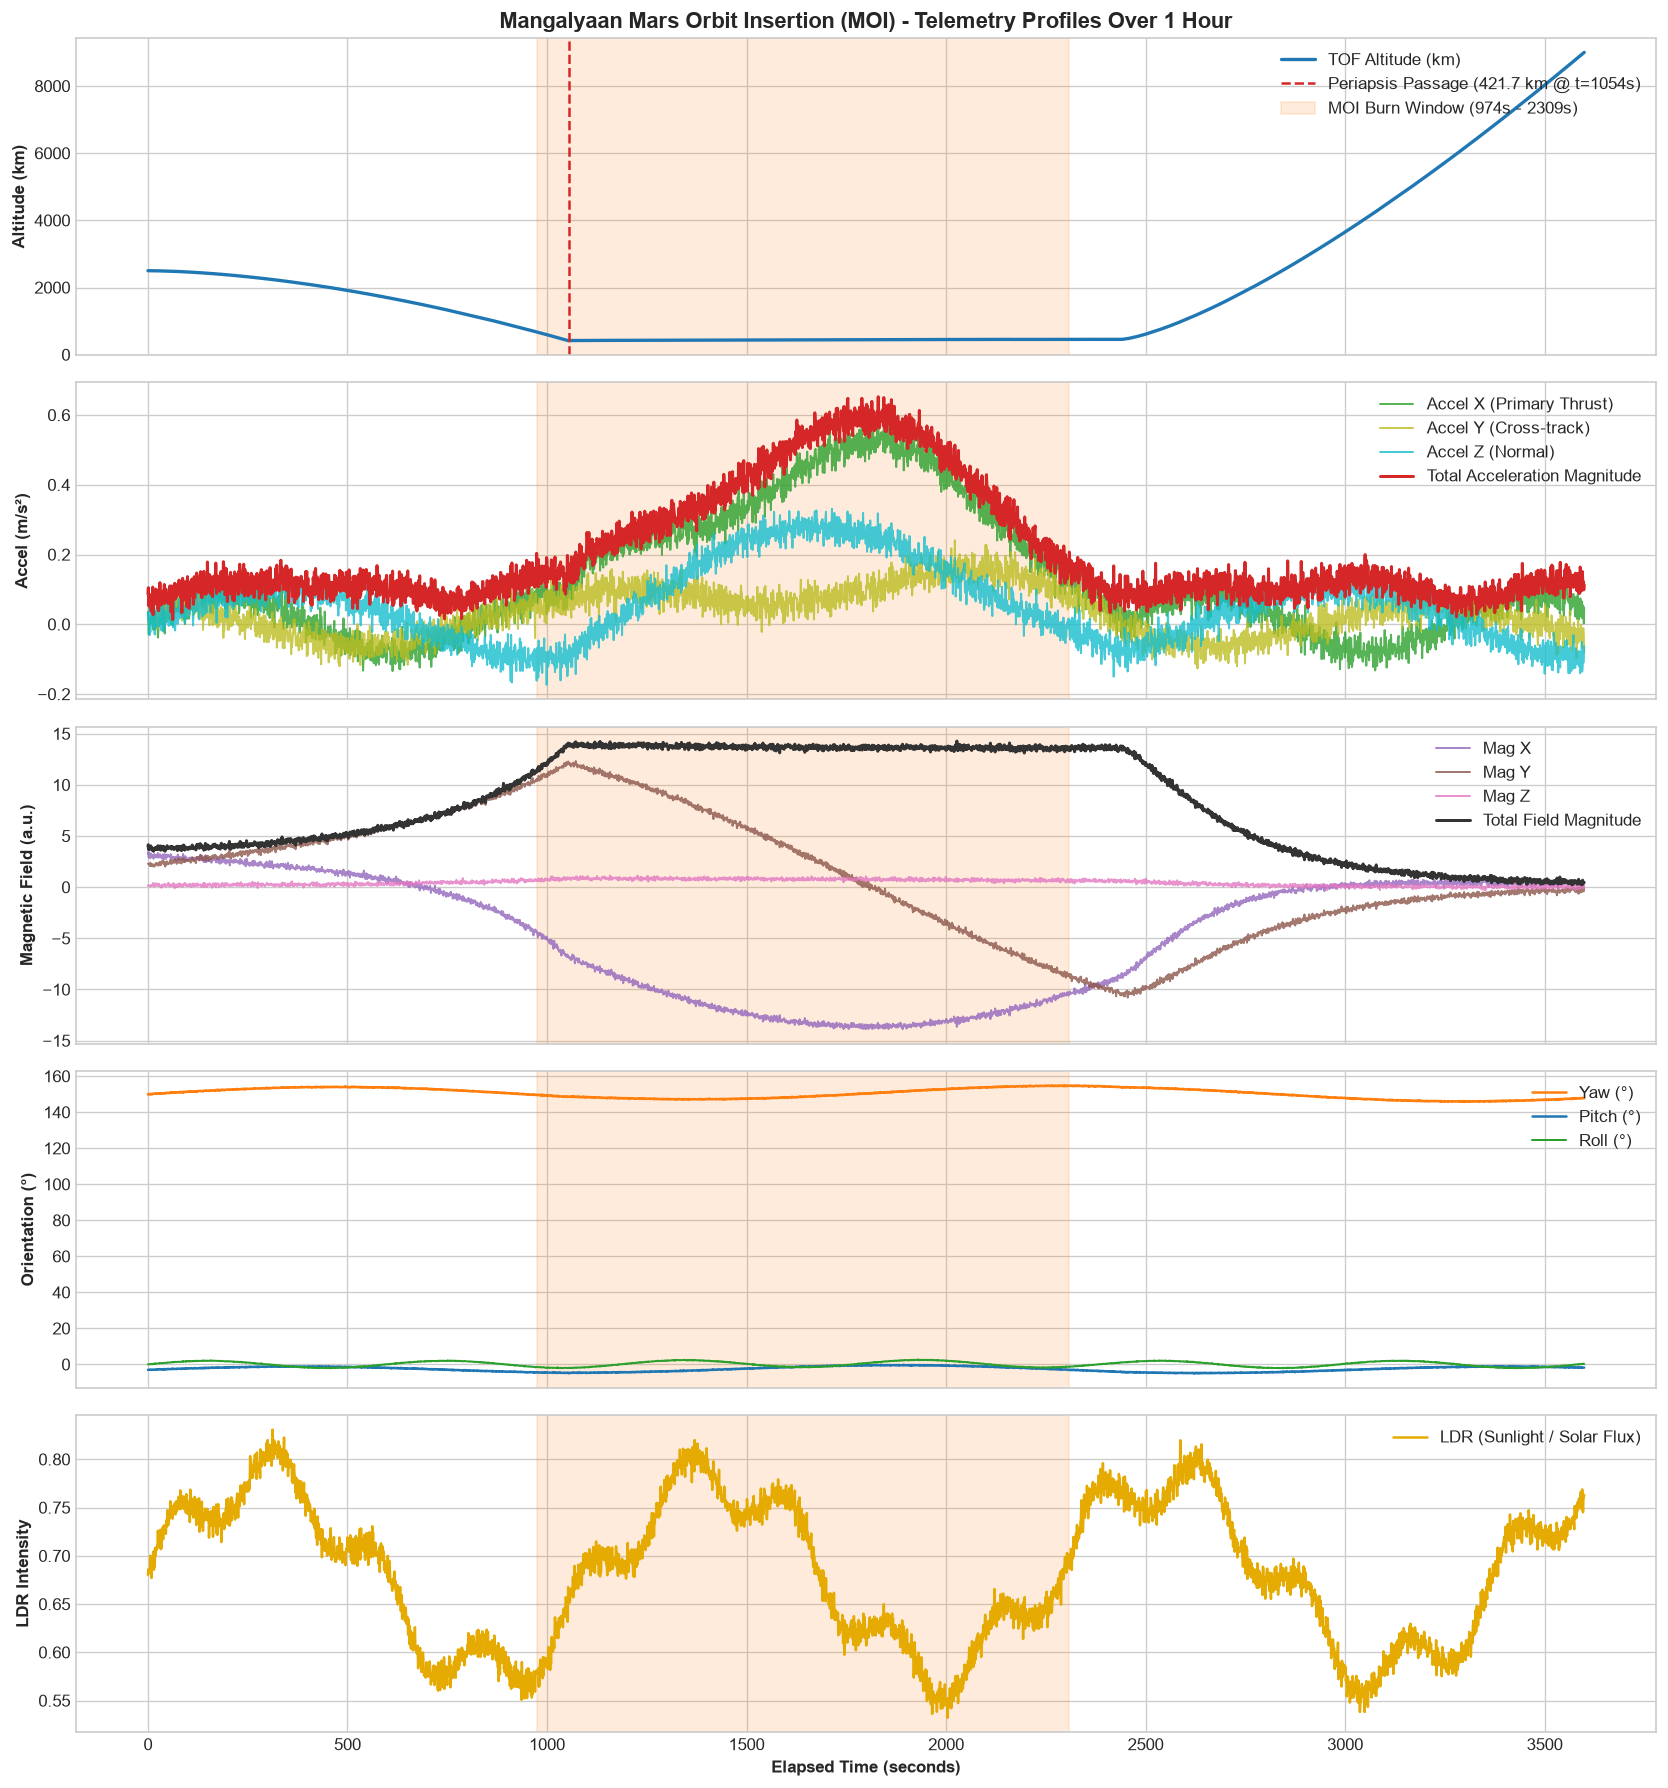

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

axes[0].plot(df['elapsed_sec'], df['TOF_Alt'], color='#1f77b4', lw=2, label='TOF Altitude (km)')
axes[0].axvline(1054, color='#d62728', linestyle='--', lw=1.5, label='Periapsis Passage (421.7 km @ t=1054s)')
axes[0].axvspan(974, 2309, color='#ff7f0e', alpha=0.15, label='MOI Burn Window (974s - 2309s)')
axes[0].set_ylabel('Altitude (km)', fontweight='bold')
axes[0].set_title('Mangalyaan Mars Orbit Insertion (MOI) - Telemetry Profiles Over 1 Hour', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')

axes[1].plot(df['elapsed_sec'], df['accelx'], color='#2ca02c', lw=1.2, alpha=0.8, label='Accel X (Primary Thrust)')
axes[1].plot(df['elapsed_sec'], df['accely'], color='#bcbd22', lw=1.2, alpha=0.8, label='Accel Y (Cross-track)')
axes[1].plot(df['elapsed_sec'], df['accelz'], color='#17becf', lw=1.2, alpha=0.8, label='Accel Z (Normal)')
axes[1].plot(df['elapsed_sec'], df['accel_mag'], color='#d62728', lw=1.8, label='Total Acceleration Magnitude')
axes[1].axvspan(974, 2309, color='#ff7f0e', alpha=0.15)
axes[1].set_ylabel('Accel (m/s²)', fontweight='bold')
axes[1].legend(loc='upper right')

axes[2].plot(df['elapsed_sec'], df['Magx'], color='#9467bd', lw=1.2, alpha=0.8, label='Mag X')
axes[2].plot(df['elapsed_sec'], df['Magy'], color='#8c564b', lw=1.2, alpha=0.8, label='Mag Y')
axes[2].plot(df['elapsed_sec'], df['Magz'], color='#e377c2', lw=1.2, alpha=0.8, label='Mag Z')
axes[2].plot(df['elapsed_sec'], df['mag_total'], color='#333333', lw=1.8, label='Total Field Magnitude')
axes[2].axvspan(974, 2309, color='#ff7f0e', alpha=0.15)
axes[2].set_ylabel('Magnetic Field (a.u.)', fontweight='bold')
axes[2].legend(loc='upper right')

axes[3].plot(df['elapsed_sec'], df['yaw'], color='#ff7f0e', lw=1.5, label='Yaw (°)')
axes[3].plot(df['elapsed_sec'], df['pitch'], color='#1f77b4', lw=1.5, label='Pitch (°)')
axes[3].plot(df['elapsed_sec'], df['angle roll'], color='#2ca02c', lw=1.2, label='Roll (°)')
axes[3].axvspan(974, 2309, color='#ff7f0e', alpha=0.15)
axes[3].set_ylabel('Orientation (°)', fontweight='bold')
axes[3].legend(loc='upper right')

axes[4].plot(df['elapsed_sec'], df['ldr'], color='#e6ab02', lw=1.5, label='LDR (Sunlight / Solar Flux)')
axes[4].axvspan(974, 2309, color='#ff7f0e', alpha=0.15)
axes[4].set_xlabel('Elapsed Time (seconds)', fontweight='bold')
axes[4].set_ylabel('LDR Intensity', fontweight='bold')
axes[4].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Correlation & Multicollinearity (VIF) Analysis
Examine linear (Pearson) and monotonic rank (Spearman) relationships between telemetry channels.

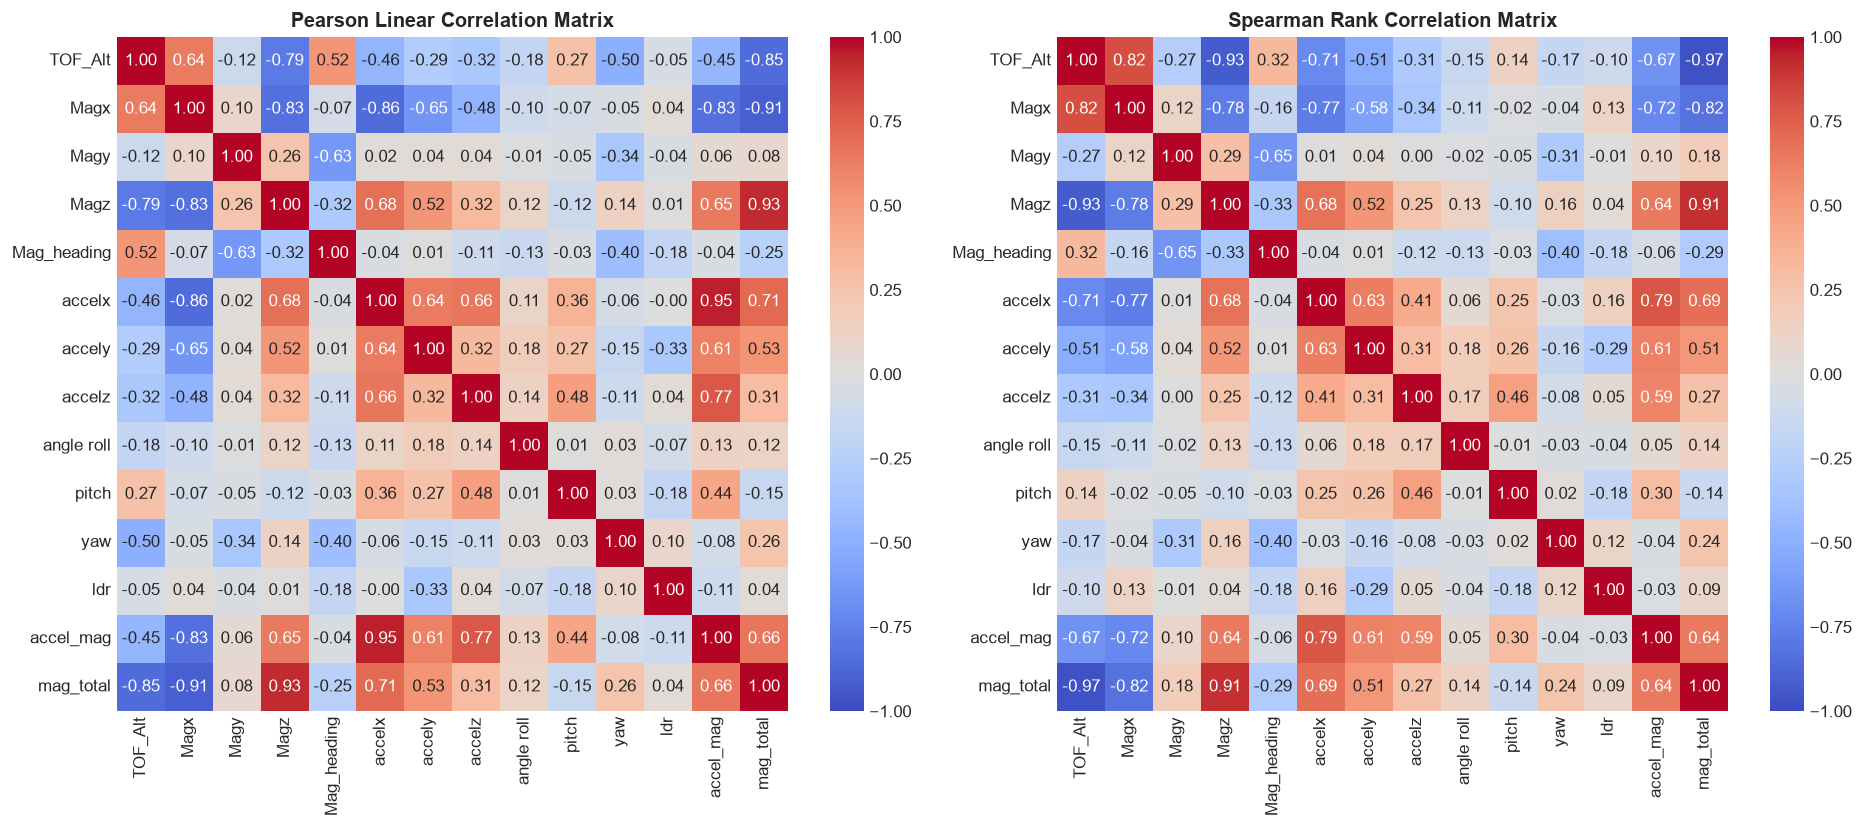

,Feature,VIF
0,TOF_Alt,24.742546
1,Magx,16.387056
9,yaw,12.496312
3,Magz,9.240310
8,pitch,9.040956
4,accelx,7.710376
6,accelz,6.548072
2,Magy,5.151379
5,accely,2.692802
10,ldr,1.401433


In [5]:
cols_for_corr = ['TOF_Alt', 'Magx', 'Magy', 'Magz', 'Mag_heading', 'accelx', 'accely', 'accelz', 'angle roll', 'pitch', 'yaw', 'ldr', 'accel_mag', 'mag_total']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

p_corr = df[cols_for_corr].corr(method='pearson')
s_corr = df[cols_for_corr].corr(method='spearman')

sns.heatmap(p_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Linear Correlation Matrix', fontweight='bold')

sns.heatmap(s_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Rank Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# VIF Multicollinearity Check
vif_features = ['TOF_Alt', 'Magx', 'Magy', 'Magz', 'accelx', 'accely', 'accelz', 'angle roll', 'pitch', 'yaw', 'ldr']
corr_matrix = df[vif_features].corr().values
vif_values = np.diag(inv(corr_matrix))
vif_df = pd.DataFrame({'Feature': vif_features, 'VIF': vif_values}).sort_values(by='VIF', ascending=False)
display(vif_df)

## 5. Physical Dependencies & Orbit Dynamics
- **Proximity Law**: Total magnetic field follows an inverse decay with altitude ($r = -0.97$).
- **Engine Braking**: Acceleration peaks at lowest altitude, providing the $\Delta V$ necessary to transition from hyperbolic encounter to bound elliptical orbit.
- **Attitude Steering**: Spaceship pitch and yaw sweep out a coordinated arc to maintain retro-burn alignment with the instantaneous velocity vector.

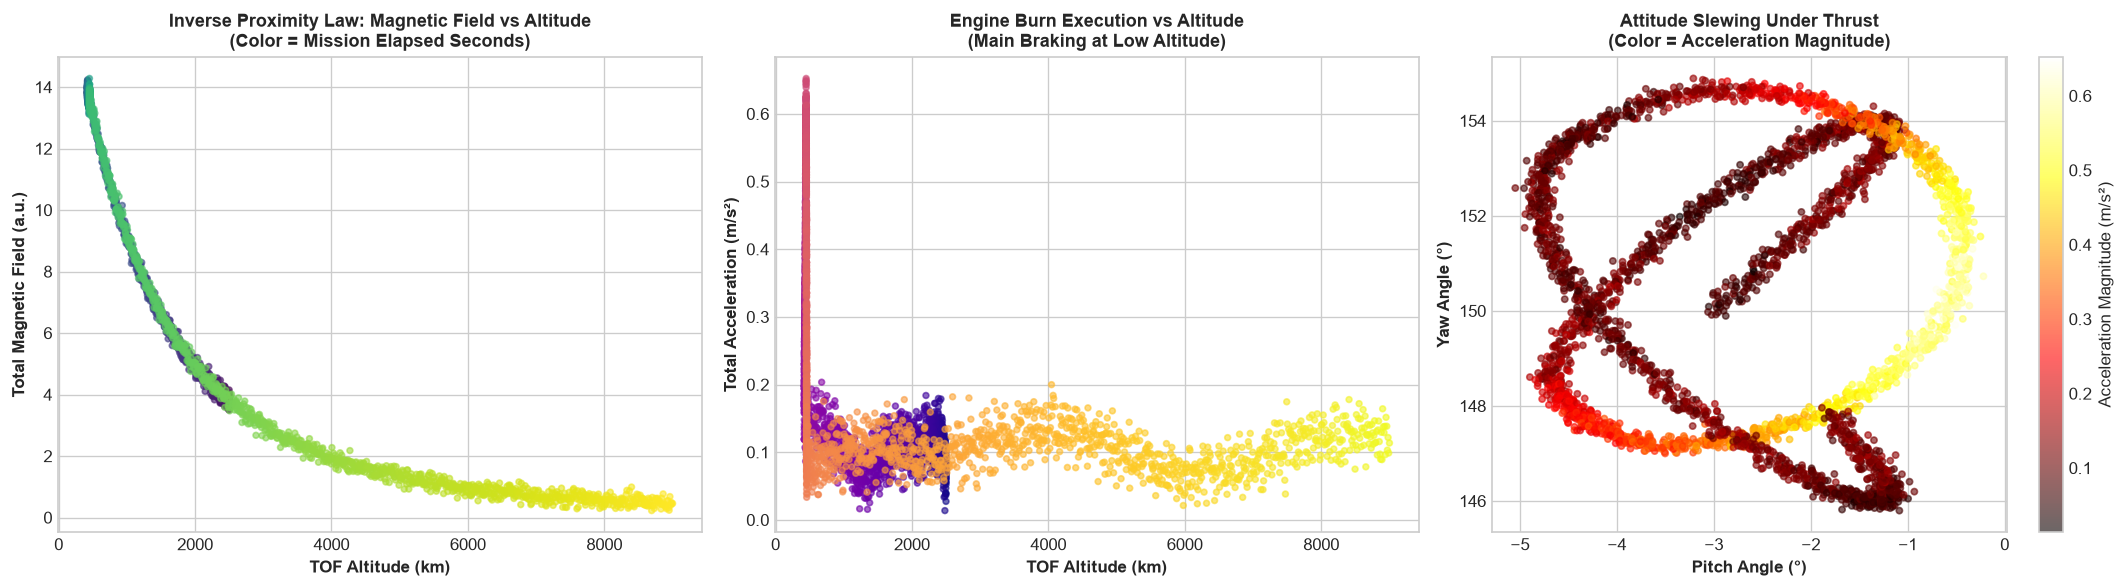

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['TOF_Alt'], df['mag_total'], c=df['elapsed_sec'], cmap='viridis', alpha=0.6, s=12)
axes[0].set_xlabel('TOF Altitude (km)', fontweight='bold')
axes[0].set_ylabel('Total Magnetic Field (a.u.)', fontweight='bold')
axes[0].set_title('Inverse Proximity Law: Magnetic Field vs Altitude\n(Color = Mission Elapsed Seconds)', fontsize=11, fontweight='bold')

axes[1].scatter(df['TOF_Alt'], df['accel_mag'], c=df['elapsed_sec'], cmap='plasma', alpha=0.6, s=12)
axes[1].set_xlabel('TOF Altitude (km)', fontweight='bold')
axes[1].set_ylabel('Total Acceleration (m/s²)', fontweight='bold')
axes[1].set_title('Engine Burn Execution vs Altitude\n(Main Braking at Low Altitude)', fontsize=11, fontweight='bold')

scatter = axes[2].scatter(df['pitch'], df['yaw'], c=df['accel_mag'], cmap='hot', alpha=0.6, s=14)
axes[2].set_xlabel('Pitch Angle (°)', fontweight='bold')
axes[2].set_ylabel('Yaw Angle (°)', fontweight='bold')
axes[2].set_title('Attitude Slewing Under Thrust\n(Color = Acceleration Magnitude)', fontsize=11, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[2])
cbar.set_label('Acceleration Magnitude (m/s²)')

plt.tight_layout()
plt.show()